# EA FC Player Retention & Onboarding Analytics

## Exploratory Data Analysis

**Objective:**  
Analyze synthetic player behavior to identify onboarding drop-offs,
engagement patterns, retention drivers, and churn patterns.

**Dataset:** 50,000 synthetic players

**Primary KPI:** Day-7 (D7) Retention

> Disclaimer: This dataset is synthetic and created for portfolio
> analysis. It does not contain proprietary EA or EA SPORTS FC data.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
df = pd.read_csv("../data/players.csv")

print("Dataset loaded successfully!")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

Dataset loaded successfully!
Rows: 50,000
Columns: 19


In [3]:
df.head()


,player_id,acquisition_date,acquisition_channel,age_group,region,platform,tutorial_completed,first_match_played,first_match_result,sessions_week1,matches_week1,avg_session_minutes,progression_level,rewards_claimed,social_feature_used,day_1_retained,day_7_retained,day_30_retained,churned
0,P000001,2026-04-13,Organic,35+,Asia Pacific,PlayStation,True,True,Draw,6,10,77.0,6,2,False,False,False,False,True
1,P000002,2026-06-29,Organic,35+,Europe,Xbox,True,True,Loss,5,7,46.0,6,3,True,True,True,True,True
2,P000003,2026-04-03,TikTok,25-34,Europe,Xbox,False,False,Not Played,9,0,40.7,5,1,True,False,False,False,True
3,P000004,2026-01-15,Paid Ads,25-34,India,PlayStation,True,True,Draw,4,9,48.2,6,2,False,False,False,False,False
4,P000005,2026-04-17,Paid Ads,18-24,Asia Pacific,PlayStation,True,True,Loss,26,55,25.5,39,11,True,True,True,False,False


In [4]:
df.tail()

,player_id,acquisition_date,acquisition_channel,age_group,region,platform,tutorial_completed,first_match_played,first_match_result,sessions_week1,matches_week1,avg_session_minutes,progression_level,rewards_claimed,social_feature_used,day_1_retained,day_7_retained,day_30_retained,churned
49995,P049996,2026-05-18,Organic,18-24,Latin America,Mobile,True,True,Draw,20,42,21.4,30,16,False,False,False,False,True
49996,P049997,2026-06-21,Instagram,35+,North America,PC,False,False,Not Played,11,0,44.1,11,7,True,True,True,False,True
49997,P049998,2026-06-09,Organic,18-24,India,PlayStation,True,True,Loss,2,3,17.4,0,0,False,True,False,False,True
49998,P049999,2026-06-21,Paid Ads,25-34,North America,PC,True,True,Draw,3,5,26.0,2,1,False,True,False,False,True
49999,P050000,2026-03-04,Influencer,18-24,Middle East & Africa,Mobile,False,False,Not Played,18,0,75.9,12,6,False,False,False,False,True


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   player_id            50000 non-null  str    
 1   acquisition_date     50000 non-null  str    
 2   acquisition_channel  50000 non-null  str    
 3   age_group            50000 non-null  str    
 4   region               50000 non-null  str    
 5   platform             50000 non-null  str    
 6   tutorial_completed   50000 non-null  bool   
 7   first_match_played   50000 non-null  bool   
 8   first_match_result   50000 non-null  str    
 9   sessions_week1       50000 non-null  int64  
 10  matches_week1        50000 non-null  int64  
 11  avg_session_minutes  50000 non-null  float64
 12  progression_level    50000 non-null  int64  
 13  rewards_claimed      50000 non-null  int64  
 14  social_feature_used  50000 non-null  bool   
 15  day_1_retained       50000 non-null  bool   
 1

In [6]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 50000
Number of columns: 19


In [7]:
missing_values = df.isnull().sum()

missing_values[missing_values > 0]

Series([], dtype: int64)

In [8]:
duplicate_players = df["player_id"].duplicated().sum()

print("Duplicate player IDs:", duplicate_players)

Duplicate player IDs: 0


In [9]:
df.describe()

,sessions_week1,matches_week1,avg_session_minutes,progression_level,rewards_claimed
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,9.746620,11.138240,38.785358,11.784620,4.273100
std,7.525904,12.310828,20.566092,9.751874,3.740363
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.000000,1.000000,24.300000,5.000000,1.000000
50%,8.000000,8.000000,36.200000,9.000000,4.000000
75%,13.000000,17.000000,50.400000,16.000000,6.000000
max,35.000000,60.000000,120.000000,50.000000,23.000000


In [10]:
categorical_columns = [
    "acquisition_channel",
    "age_group",
    "region",
    "platform"
]

for column in categorical_columns:
    print(f"\n{column}")
    print(df[column].value_counts())


acquisition_channel
acquisition_channel
Organic       12431
Paid Ads      10001
Instagram      7518
TikTok         7512
YouTube        7483
Influencer     5055
Name: count, dtype: int64

age_group
age_group
18-24       22457
25-34       12401
Under 18     7648
35+          7494
Name: count, dtype: int64

region
region
Europe                  12469
India                   12336
North America           10001
Asia Pacific             7620
Latin America            4984
Middle East & Africa     2590
Name: count, dtype: int64

platform
platform
PlayStation    17290
PC             12591
Xbox           10065
Mobile         10054
Name: count, dtype: int64


In [11]:
df["acquisition_date"] = pd.to_datetime(
    df["acquisition_date"]
)

print(df["acquisition_date"].dtype)

datetime64[us]


In [12]:
print(
    "Earliest acquisition:",
    df["acquisition_date"].min()
)

print(
    "Latest acquisition:",
    df["acquisition_date"].max()
)

Earliest acquisition: 2026-01-01 00:00:00
Latest acquisition: 2026-06-30 00:00:00


## 1. Player Population Analysis

Before analyzing retention, we first understand the composition of the player base across acquisition channels, regions, platforms, and age groups.

In [13]:
population_summary = {
    "Total Players": len(df),
    "Tutorial Completion": df["tutorial_completed"].mean(),
    "First Match Conversion": df["first_match_played"].mean(),
    "Social Feature Adoption": df["social_feature_used"].mean(),
    "D1 Retention": df["day_1_retained"].mean(),
    "D7 Retention": df["day_7_retained"].mean(),
    "D30 Retention": df["day_30_retained"].mean(),
    "Churn Rate": df["churned"].mean()
}

population_summary

{'Total Players': 50000,
 'Tutorial Completion': np.float64(0.75542),
 'First Match Conversion': np.float64(0.7509),
 'Social Feature Adoption': np.float64(0.3373),
 'D1 Retention': np.float64(0.52662),
 'D7 Retention': np.float64(0.32684),
 'D30 Retention': np.float64(0.2019),
 'Churn Rate': np.float64(0.70934)}

In [14]:
channel_distribution = (
    df["acquisition_channel"]
    .value_counts()
    .reset_index()
)

channel_distribution.columns = [
    "acquisition_channel",
    "players"
]

channel_distribution

,acquisition_channel,players
0,Organic,12431
1,Paid Ads,10001
2,Instagram,7518
3,TikTok,7512
4,YouTube,7483
5,Influencer,5055


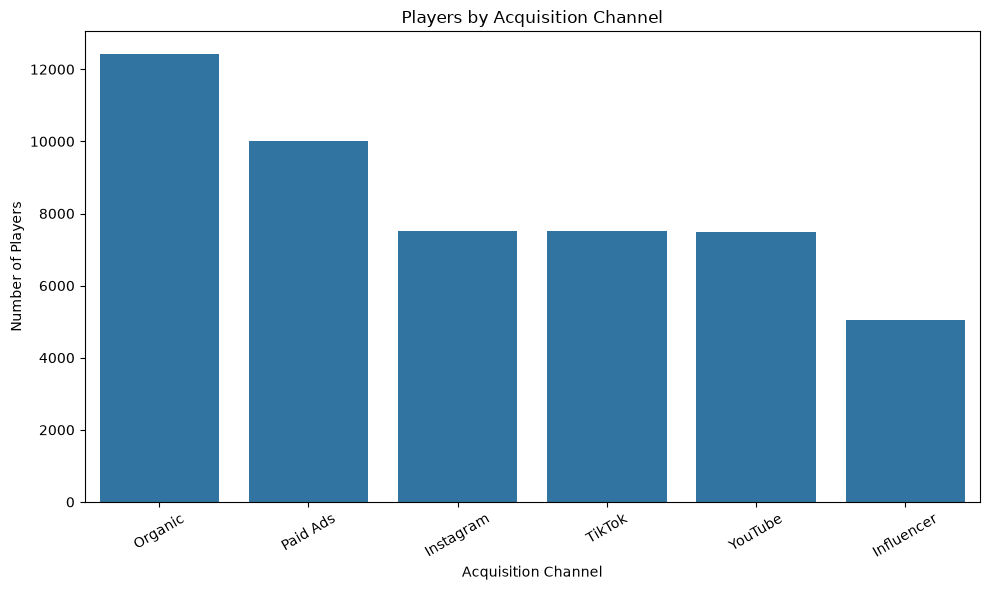

In [15]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=channel_distribution,
    x="acquisition_channel",
    y="players"
)

plt.title("Players by Acquisition Channel")
plt.xlabel("Acquisition Channel")
plt.ylabel("Number of Players")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

In [16]:
platform_distribution = (
    df["platform"]
    .value_counts()
    .reset_index()
)

platform_distribution.columns = [
    "platform",
    "players"
]

platform_distribution

,platform,players
0,PlayStation,17290
1,PC,12591
2,Xbox,10065
3,Mobile,10054


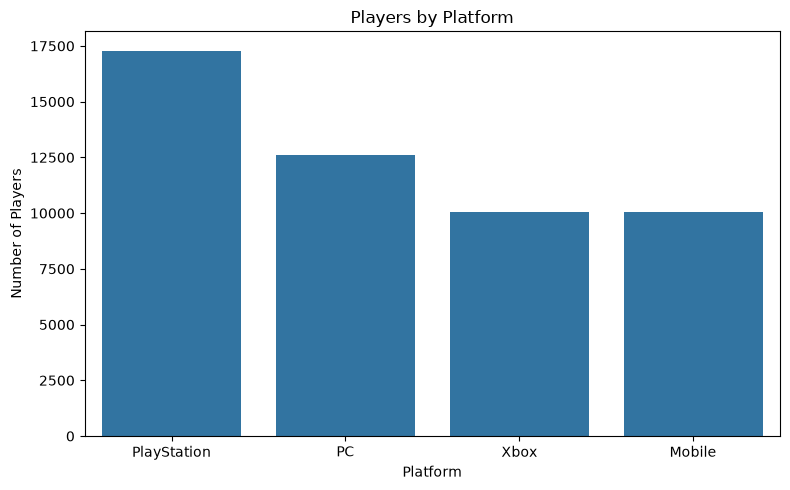

In [17]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=platform_distribution,
    x="platform",
    y="players"
)

plt.title("Players by Platform")
plt.xlabel("Platform")
plt.ylabel("Number of Players")

plt.tight_layout()
plt.show()

In [18]:
age_distribution = (
    df["age_group"]
    .value_counts()
    .reindex([
        "Under 18",
        "18-24",
        "25-34",
        "35+"
    ])
    .reset_index()
)

age_distribution.columns = [
    "age_group",
    "players"
]

age_distribution

,age_group,players
0,Under 18,7648
1,18-24,22457
2,25-34,12401
3,35+,7494


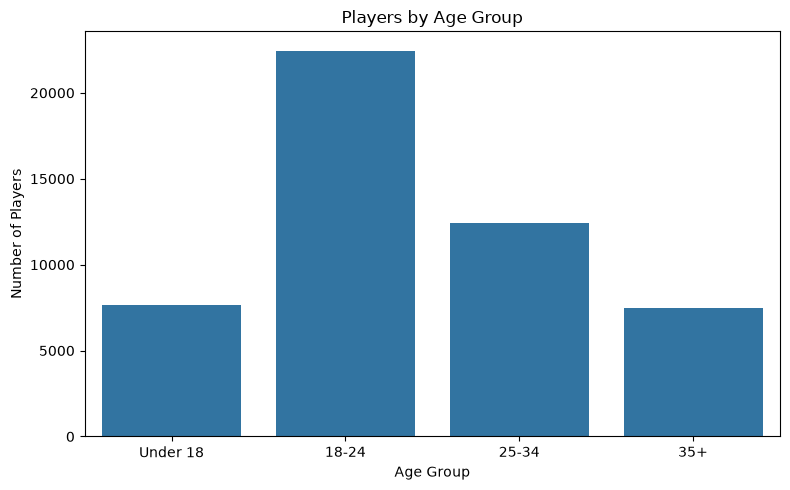

In [19]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=age_distribution,
    x="age_group",
    y="players"
)

plt.title("Players by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Players")

plt.tight_layout()
plt.show()

## 2. New Player Onboarding Funnel

The onboarding funnel measures how players progress through the first stages of their product journey, from acquisition to early engagement and Day-7 retention.

In [20]:
funnel = pd.DataFrame({
    "Stage": [
        "New Players",
        "Tutorial Completed",
        "First Match Played",
        "Second Session",
        "D7 Retained"
    ],
    "Players": [
        len(df),
        df["tutorial_completed"].sum(),
        df["first_match_played"].sum(),
        (df["sessions_week1"] >= 2).sum(),
        df["day_7_retained"].sum()
    ]
})

funnel

,Stage,Players
0,New Players,50000
1,Tutorial Completed,37771
2,First Match Played,37545
3,Second Session,45900
4,D7 Retained,16342


In [21]:
funnel["Conversion_Rate"] = (
    funnel["Players"] / funnel.loc[0, "Players"]
)

funnel["Conversion_Rate"] = (
    funnel["Conversion_Rate"] * 100
).round(2)

funnel

,Stage,Players,Conversion_Rate
0,New Players,50000,100.00
1,Tutorial Completed,37771,75.54
2,First Match Played,37545,75.09
3,Second Session,45900,91.80
4,D7 Retained,16342,32.68


In [22]:
funnel["Stage_to_Stage_Conversion"] = (
    funnel["Players"]
    .div(funnel["Players"].shift(1))
    * 100
)

funnel["Stage_to_Stage_Conversion"] = (
    funnel["Stage_to_Stage_Conversion"]
    .round(2)
)

funnel

,Stage,Players,Conversion_Rate,Stage_to_Stage_Conversion
0,New Players,50000,100.00,NaN
1,Tutorial Completed,37771,75.54,75.54
2,First Match Played,37545,75.09,99.40
3,Second Session,45900,91.80,122.25
4,D7 Retained,16342,32.68,35.60


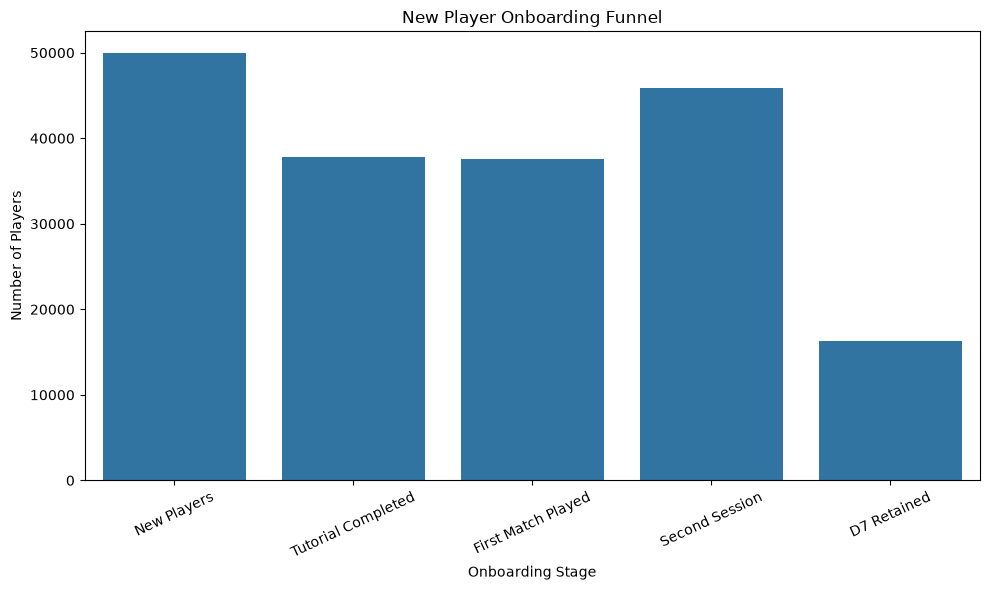

In [23]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=funnel,
    x="Stage",
    y="Players"
)

plt.title("New Player Onboarding Funnel")
plt.xlabel("Onboarding Stage")
plt.ylabel("Number of Players")
plt.xticks(rotation=25)

plt.tight_layout()
plt.show()

In [24]:
funnel["Players_Lost"] = (
    funnel["Players"].shift(1)
    - funnel["Players"]
)

funnel

,Stage,Players,Conversion_Rate,Stage_to_Stage_Conversion,Players_Lost
0,New Players,50000,100.00,NaN,NaN
1,Tutorial Completed,37771,75.54,75.54,12229.0
2,First Match Played,37545,75.09,99.40,226.0
3,Second Session,45900,91.80,122.25,-8355.0
4,D7 Retained,16342,32.68,35.60,29558.0


In [25]:
largest_drop = funnel.loc[
    funnel["Players_Lost"].idxmax()
]

print(
    "Largest player drop occurs at:",
    largest_drop["Stage"]
)

print(
    "Players lost:",
    int(largest_drop["Players_Lost"])
)

Largest player drop occurs at: D7 Retained
Players lost: 29558


## 3. Onboarding Impact on D7 Retention

This analysis compares Day-7 retention between players who completed the tutorial and players who did not.

In [26]:
tutorial_retention = (
    df.groupby("tutorial_completed")["day_7_retained"]
    .mean()
    .reset_index()
)

tutorial_retention["day_7_retained"] = (
    tutorial_retention["day_7_retained"] * 100
).round(2)

tutorial_retention

,tutorial_completed,day_7_retained
0,False,13.09
1,True,39.03


In [27]:
tutorial_retention["tutorial_completed"] = (
    tutorial_retention["tutorial_completed"]
    .map({
        True: "Completed",
        False: "Not Completed"
    })
)

tutorial_retention

,tutorial_completed,day_7_retained
0,Not Completed,13.09
1,Completed,39.03


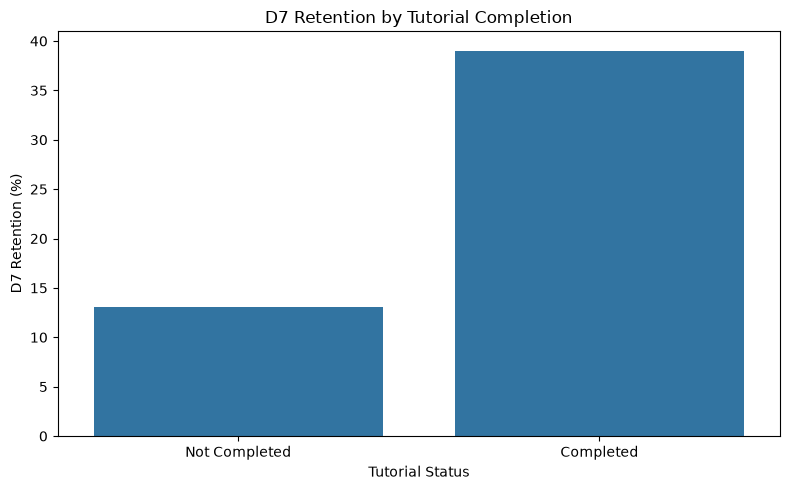

In [28]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=tutorial_retention,
    x="tutorial_completed",
    y="day_7_retained"
)

plt.title("D7 Retention by Tutorial Completion")
plt.xlabel("Tutorial Status")
plt.ylabel("D7 Retention (%)")

plt.tight_layout()
plt.show()

In [29]:
completed_rate = (
    df.loc[
        df["tutorial_completed"] == True,
        "day_7_retained"
    ].mean()
)

not_completed_rate = (
    df.loc[
        df["tutorial_completed"] == False,
        "day_7_retained"
    ].mean()
)

retention_gap = (
    completed_rate - not_completed_rate
) * 100

print(
    f"D7 retention gap: {retention_gap:.2f} percentage points"
)

D7 retention gap: 25.94 percentage points


In [30]:
first_match_retention = (
    df.groupby("first_match_played")["day_7_retained"]
    .mean()
    .reset_index()
)

first_match_retention["day_7_retained"] = (
    first_match_retention["day_7_retained"] * 100
).round(2)

first_match_retention["first_match_played"] = (
    first_match_retention["first_match_played"]
    .map({
        True: "Played First Match",
        False: "Did Not Play First Match"
    })
)

first_match_retention

,first_match_played,day_7_retained
0,Did Not Play First Match,9.91
1,Played First Match,40.24


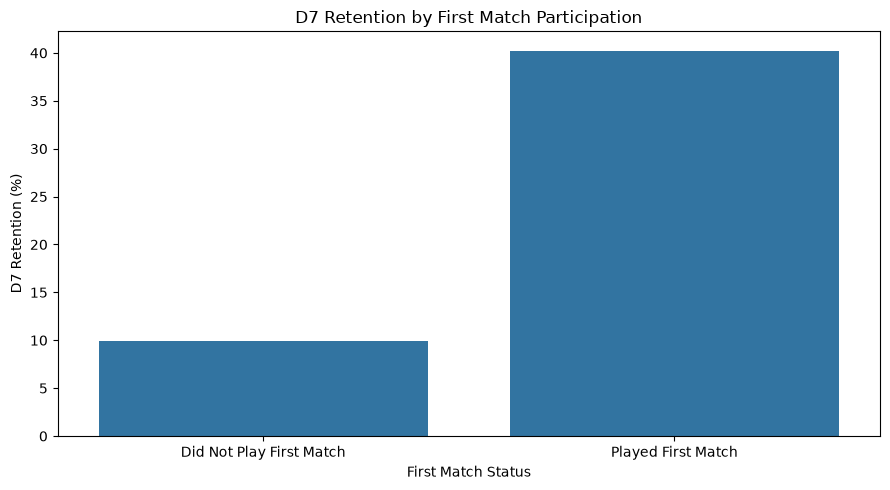

In [31]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=first_match_retention,
    x="first_match_played",
    y="day_7_retained"
)

plt.title("D7 Retention by First Match Participation")
plt.xlabel("First Match Status")
plt.ylabel("D7 Retention (%)")

plt.tight_layout()
plt.show()

## 4. Engagement vs D7 Retention

This analysis examines whether higher Week-1 engagement is associated with stronger Day-7 retention.

In [32]:
df["session_bucket"] = pd.cut(
    df["sessions_week1"],
    bins=[-1, 3, 10, 20, 35],
    labels=[
        "Low (0-3)",
        "Moderate (4-10)",
        "High (11-20)",
        "Very High (21-35)"
    ]
)

df["session_bucket"].value_counts().sort_index()

session_bucket
Low (0-3)            10296
Moderate (4-10)      22511
High (11-20)         12885
Very High (21-35)     4308
Name: count, dtype: int64

In [33]:
session_retention = (
    df.groupby(
        "session_bucket",
        observed=True
    )["day_7_retained"]
    .mean()
    .reset_index()
)

session_retention["d7_retention_pct"] = (
    session_retention["day_7_retained"] * 100
).round(2)

session_retention

,session_bucket,day_7_retained,d7_retention_pct
0,Low (0-3),0.157537,15.75
1,Moderate (4-10),0.271645,27.16
2,High (11-20),0.442685,44.27
3,Very High (21-35),0.673398,67.34


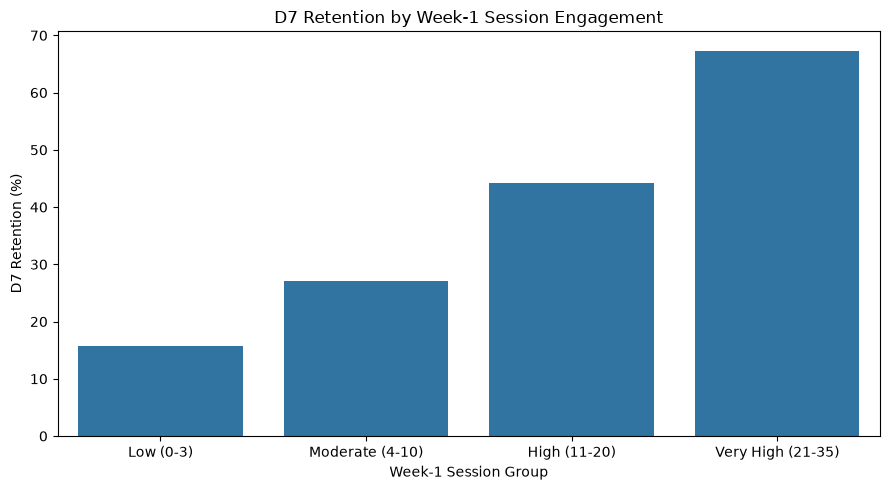

In [34]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=session_retention,
    x="session_bucket",
    y="d7_retention_pct"
)

plt.title("D7 Retention by Week-1 Session Engagement")
plt.xlabel("Week-1 Session Group")
plt.ylabel("D7 Retention (%)")

plt.tight_layout()
plt.show()

In [35]:
low_retention = session_retention.loc[
    session_retention["session_bucket"] == "Low (0-3)",
    "d7_retention_pct"
].iloc[0]

very_high_retention = session_retention.loc[
    session_retention["session_bucket"] == "Very High (21-35)",
    "d7_retention_pct"
].iloc[0]

engagement_gap = very_high_retention - low_retention

print(
    f"D7 retention gap between low and very-high engagement: "
    f"{engagement_gap:.2f} percentage points"
)

D7 retention gap between low and very-high engagement: 51.59 percentage points


## 5. Retained vs Churned Player Profiles

This analysis compares player behavior across retention and churn outcomes to identify behavioral patterns associated with stronger player retention.

In [36]:
profile_summary = df.groupby("day_7_retained").agg(
    avg_sessions=("sessions_week1", "mean"),
    avg_matches=("matches_week1", "mean"),
    avg_session_minutes=("avg_session_minutes", "mean"),
    avg_progression=("progression_level", "mean"),
    avg_rewards=("rewards_claimed", "mean"),
    tutorial_completion=("tutorial_completed", "mean"),
    first_match_rate=("first_match_played", "mean"),
    social_adoption=("social_feature_used", "mean"),
    churn_rate=("churned", "mean")
).reset_index()

profile_summary

,day_7_retained,avg_sessions,avg_matches,avg_session_minutes,avg_progression,avg_rewards,tutorial_completion,first_match_rate,social_adoption,churn_rate
0,False,8.073890,7.701468,38.025902,9.240032,3.414404,0.684236,0.666617,0.310803,0.764751
1,True,13.191776,18.216620,40.349535,17.025456,6.041672,0.902032,0.924489,0.391874,0.595215


In [37]:
profile_display = profile_summary.copy()

profile_display["day_7_retained"] = (
    profile_display["day_7_retained"]
    .map({
        True: "D7 Retained",
        False: "Not D7 Retained"
    })
)

percentage_columns = [
    "tutorial_completion",
    "first_match_rate",
    "social_adoption",
    "churn_rate"
]

profile_display[percentage_columns] = (
    profile_display[percentage_columns] * 100
).round(2)

profile_display

,day_7_retained,avg_sessions,avg_matches,avg_session_minutes,avg_progression,avg_rewards,tutorial_completion,first_match_rate,social_adoption,churn_rate
0,Not D7 Retained,8.073890,7.701468,38.025902,9.240032,3.414404,68.42,66.66,31.08,76.48
1,D7 Retained,13.191776,18.216620,40.349535,17.025456,6.041672,90.20,92.45,39.19,59.52


In [38]:
engagement_comparison = profile_display[
    [
        "day_7_retained",
        "avg_sessions",
        "avg_matches",
        "avg_session_minutes"
    ]
]

engagement_comparison

,day_7_retained,avg_sessions,avg_matches,avg_session_minutes
0,Not D7 Retained,8.073890,7.701468,38.025902
1,D7 Retained,13.191776,18.216620,40.349535


In [39]:
progression_comparison = profile_display[
    [
        "day_7_retained",
        "avg_progression",
        "avg_rewards"
    ]
]

progression_comparison

,day_7_retained,avg_progression,avg_rewards
0,Not D7 Retained,9.240032,3.414404
1,D7 Retained,17.025456,6.041672


In [40]:
onboarding_comparison = profile_display[
    [
        "day_7_retained",
        "tutorial_completion",
        "first_match_rate",
        "social_adoption"
    ]
]

onboarding_comparison

,day_7_retained,tutorial_completion,first_match_rate,social_adoption
0,Not D7 Retained,68.42,66.66,31.08
1,D7 Retained,90.20,92.45,39.19


In [41]:
behavior_metrics = pd.DataFrame({
    "Metric": [
        "Sessions",
        "Matches",
        "Session Duration",
        "Progression",
        "Rewards"
    ],
    "D7 Retained": [
        profile_summary.loc[
            profile_summary["day_7_retained"] == True,
            "avg_sessions"
        ].iloc[0],

        profile_summary.loc[
            profile_summary["day_7_retained"] == True,
            "avg_matches"
        ].iloc[0],

        profile_summary.loc[
            profile_summary["day_7_retained"] == True,
            "avg_session_minutes"
        ].iloc[0],

        profile_summary.loc[
            profile_summary["day_7_retained"] == True,
            "avg_progression"
        ].iloc[0],

        profile_summary.loc[
            profile_summary["day_7_retained"] == True,
            "avg_rewards"
        ].iloc[0]
    ],
    "Not D7 Retained": [
        profile_summary.loc[
            profile_summary["day_7_retained"] == False,
            "avg_sessions"
        ].iloc[0],

        profile_summary.loc[
            profile_summary["day_7_retained"] == False,
            "avg_matches"
        ].iloc[0],

        profile_summary.loc[
            profile_summary["day_7_retained"] == False,
            "avg_session_minutes"
        ].iloc[0],

        profile_summary.loc[
            profile_summary["day_7_retained"] == False,
            "avg_progression"
        ].iloc[0],

        profile_summary.loc[
            profile_summary["day_7_retained"] == False,
            "avg_rewards"
        ].iloc[0]
    ]
})

behavior_metrics

,Metric,D7 Retained,Not D7 Retained
0,Sessions,13.191776,8.073890
1,Matches,18.216620,7.701468
2,Session Duration,40.349535,38.025902
3,Progression,17.025456,9.240032
4,Rewards,6.041672,3.414404


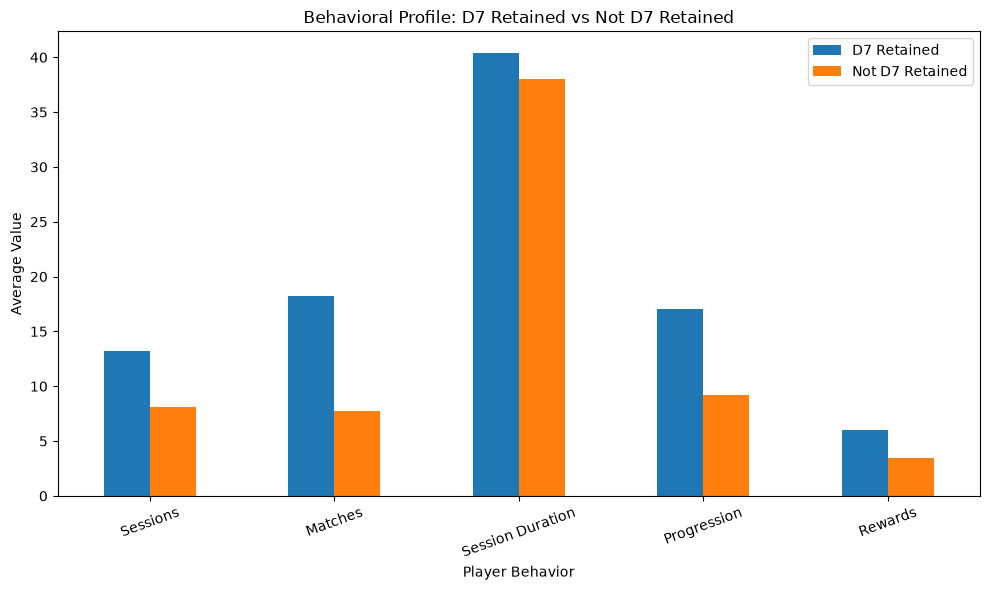

In [42]:
behavior_metrics.plot(
    x="Metric",
    y=["D7 Retained", "Not D7 Retained"],
    kind="bar",
    figsize=(10, 6)
)

plt.title("Behavioral Profile: D7 Retained vs Not D7 Retained")
plt.xlabel("Player Behavior")
plt.ylabel("Average Value")
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

In [43]:
retained = profile_summary[
    profile_summary["day_7_retained"] == True
].iloc[0]

not_retained = profile_summary[
    profile_summary["day_7_retained"] == False
].iloc[0]

comparison = pd.DataFrame({
    "Metric": [
        "Sessions",
        "Matches",
        "Session Duration",
        "Progression",
        "Rewards"
    ],
    "D7 Retained": [
        retained["avg_sessions"],
        retained["avg_matches"],
        retained["avg_session_minutes"],
        retained["avg_progression"],
        retained["avg_rewards"]
    ],
    "Not D7 Retained": [
        not_retained["avg_sessions"],
        not_retained["avg_matches"],
        not_retained["avg_session_minutes"],
        not_retained["avg_progression"],
        not_retained["avg_rewards"]
    ]
})

comparison["Difference"] = (
    comparison["D7 Retained"]
    - comparison["Not D7 Retained"]
)

comparison["Difference_%"] = (
    comparison["Difference"]
    / comparison["Not D7 Retained"]
    * 100
).round(2)

comparison.round(2)

,Metric,D7 Retained,Not D7 Retained,Difference,Difference_%
0,Sessions,13.19,8.07,5.12,63.39
1,Matches,18.22,7.70,10.52,136.53
2,Session Duration,40.35,38.03,2.32,6.11
3,Progression,17.03,9.24,7.79,84.26
4,Rewards,6.04,3.41,2.63,76.95


In [44]:
strongest_signal = comparison.loc[
    comparison["Difference_%"].abs().idxmax()
]

print("Strongest behavioral difference:")
print(strongest_signal)

Strongest behavioral difference:
Metric               Matches
D7 Retained         18.21662
Not D7 Retained     7.701468
Difference         10.515152
Difference_%          136.53
Name: 1, dtype: object


### Key Insight

D7-retained players demonstrate stronger early-game engagement and progression than non-retained players. The largest behavioral differences are observed in session frequency, match participation, progression, and reward activity.

This indicates that successful early engagement and progression are important behavioral signals associated with D7 retention.

These relationships are observational and do not establish causality.

## 6. Social Feature Impact

This analysis evaluates the relationship between social feature usage and Day-7 retention.

In [45]:
social_adoption = (
    df["social_feature_used"]
    .mean() * 100
)

print(
    f"Overall social feature adoption: "
    f"{social_adoption:.2f}%"
)

Overall social feature adoption: 33.73%


In [46]:
social_retention = (
    df.groupby("social_feature_used")["day_7_retained"]
    .mean()
    .reset_index()
)

social_retention["d7_retention_pct"] = (
    social_retention["day_7_retained"] * 100
).round(2)

social_retention["social_feature_used"] = (
    social_retention["social_feature_used"]
    .map({
        True: "Used Social Feature",
        False: "Did Not Use Social"
    })
)

social_retention

,social_feature_used,day_7_retained,d7_retention_pct
0,Did Not Use Social,0.299925,29.99
1,Used Social Feature,0.379721,37.97


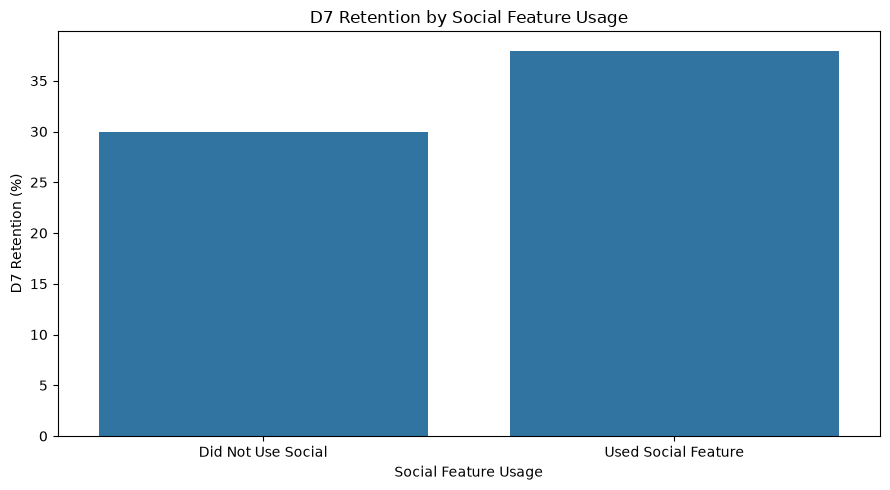

In [47]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=social_retention,
    x="social_feature_used",
    y="d7_retention_pct"
)

plt.title("D7 Retention by Social Feature Usage")
plt.xlabel("Social Feature Usage")
plt.ylabel("D7 Retention (%)")

plt.tight_layout()
plt.show()

In [48]:
social_used_rate = (
    df.loc[
        df["social_feature_used"] == True,
        "day_7_retained"
    ].mean()
)

social_not_used_rate = (
    df.loc[
        df["social_feature_used"] == False,
        "day_7_retained"
    ].mean()
)

social_gap = (
    social_used_rate - social_not_used_rate
) * 100

print(
    f"D7 retention gap associated with social usage: "
    f"{social_gap:.2f} percentage points"
)

D7 retention gap associated with social usage: 7.98 percentage points


## 7. Acquisition Channel Quality

This analysis compares acquisition channels based on both player volume and Day-7 retention to identify channels that attract higher-quality players.

In [49]:
channel_performance = (
    df.groupby("acquisition_channel")
    .agg(
        players=("player_id", "count"),
        d7_retention=("day_7_retained", "mean"),
        churn_rate=("churned", "mean"),
        avg_sessions=("sessions_week1", "mean"),
        avg_matches=("matches_week1", "mean")
    )
    .reset_index()
)

channel_performance["player_share"] = (
    channel_performance["players"]
    / len(df)
    * 100
)

channel_performance["d7_retention"] = (
    channel_performance["d7_retention"]
    * 100
)

channel_performance["churn_rate"] = (
    channel_performance["churn_rate"]
    * 100
)

channel_performance = channel_performance.round(2)

channel_performance.sort_values(
    "d7_retention",
    ascending=False
)

,acquisition_channel,players,d7_retention,churn_rate,avg_sessions,avg_matches,player_share
2,Organic,12431,33.79,69.45,9.78,11.58,24.86
0,Influencer,5055,33.51,71.04,9.77,11.42,10.11
1,Instagram,7518,32.59,72.36,9.53,10.88,15.04
4,TikTok,7512,32.51,70.31,9.81,11.08,15.02
5,YouTube,7483,32.37,71.07,9.76,11.11,14.97
3,Paid Ads,10001,31.33,72.02,9.81,10.71,20.00


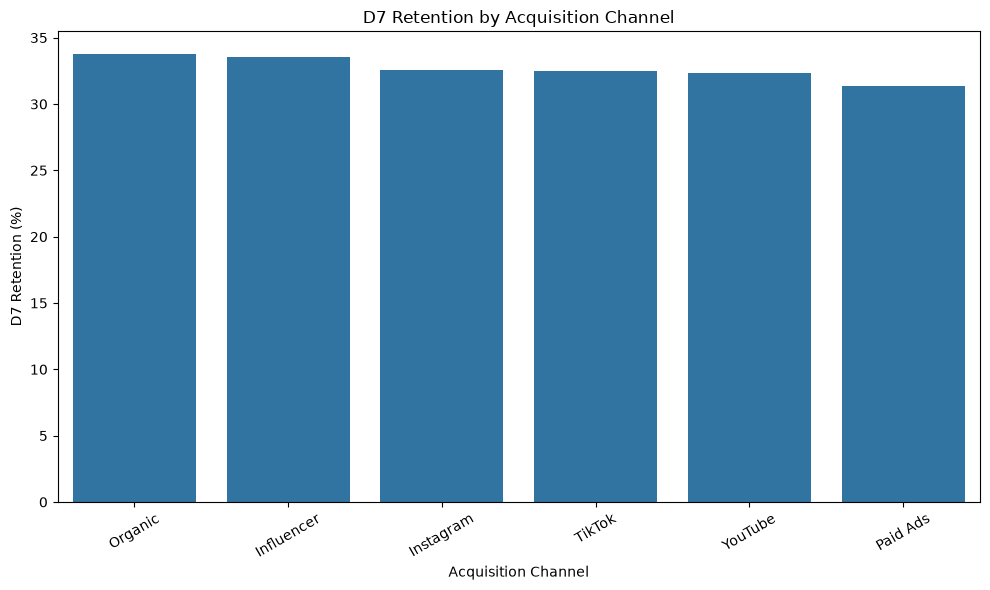

In [51]:
plt.figure(figsize=(10, 6))

channel_sorted = channel_performance.sort_values(
    "d7_retention",
    ascending=False
)

sns.barplot(
    data=channel_sorted,
    x="acquisition_channel",
    y="d7_retention"
)

plt.title("D7 Retention by Acquisition Channel")
plt.xlabel("Acquisition Channel")
plt.ylabel("D7 Retention (%)")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

In [52]:
channel_quality = channel_performance[
    [
        "acquisition_channel",
        "players",
        "player_share",
        "d7_retention",
        "churn_rate",
        "avg_sessions",
        "avg_matches"
    ]
].sort_values(
    "d7_retention",
    ascending=False
)

channel_quality

,acquisition_channel,players,player_share,d7_retention,churn_rate,avg_sessions,avg_matches
2,Organic,12431,24.86,33.79,69.45,9.78,11.58
0,Influencer,5055,10.11,33.51,71.04,9.77,11.42
1,Instagram,7518,15.04,32.59,72.36,9.53,10.88
4,TikTok,7512,15.02,32.51,70.31,9.81,11.08
5,YouTube,7483,14.97,32.37,71.07,9.76,11.11
3,Paid Ads,10001,20.00,31.33,72.02,9.81,10.71


In [53]:
best_channel = channel_performance.loc[
    channel_performance["d7_retention"].idxmax()
]

print(
    "Highest D7 retention channel:",
    best_channel["acquisition_channel"]
)

print(
    f"D7 retention: "
    f"{best_channel['d7_retention']:.2f}%"
)

Highest D7 retention channel: Organic
D7 retention: 33.79%


In [54]:
largest_channel = channel_performance.loc[
    channel_performance["players"].idxmax()
]

print(
    "Largest acquisition channel:",
    largest_channel["acquisition_channel"]
)

print(
    f"Players acquired: "
    f"{int(largest_channel['players']):,}"
)

print(
    f"Player share: "
    f"{largest_channel['player_share']:.2f}%"
)

Largest acquisition channel: Organic
Players acquired: 12,431
Player share: 24.86%


## 8. Acquisition Channel Strategy

Acquisition channels are evaluated using both scale and player quality. This helps distinguish channels that should be scaled, optimized, or investigated further.

In [55]:
channel_strategy = channel_performance.copy()

channel_strategy["strategy"] = np.select(
    [
        (
            (channel_strategy["player_share"] >= 20)
            & (channel_strategy["d7_retention"] >= 33)
        ),

        (
            (channel_strategy["player_share"] < 15)
            & (channel_strategy["d7_retention"] >= 33)
        ),

        (
            (channel_strategy["player_share"] >= 15)
            & (channel_strategy["d7_retention"] < 32)
        )
    ],
    [
        "Scale + Quality",
        "High Quality / Lower Scale",
        "Scale but Optimize"
    ],
    default="Monitor"
)

channel_strategy[
    [
        "acquisition_channel",
        "player_share",
        "d7_retention",
        "churn_rate",
        "strategy"
    ]
].sort_values(
    "d7_retention",
    ascending=False
)

,acquisition_channel,player_share,d7_retention,churn_rate,strategy
2,Organic,24.86,33.79,69.45,Scale + Quality
0,Influencer,10.11,33.51,71.04,High Quality / Lower Scale
1,Instagram,15.04,32.59,72.36,Monitor
4,TikTok,15.02,32.51,70.31,Monitor
5,YouTube,14.97,32.37,71.07,Monitor
3,Paid Ads,20.00,31.33,72.02,Scale but Optimize


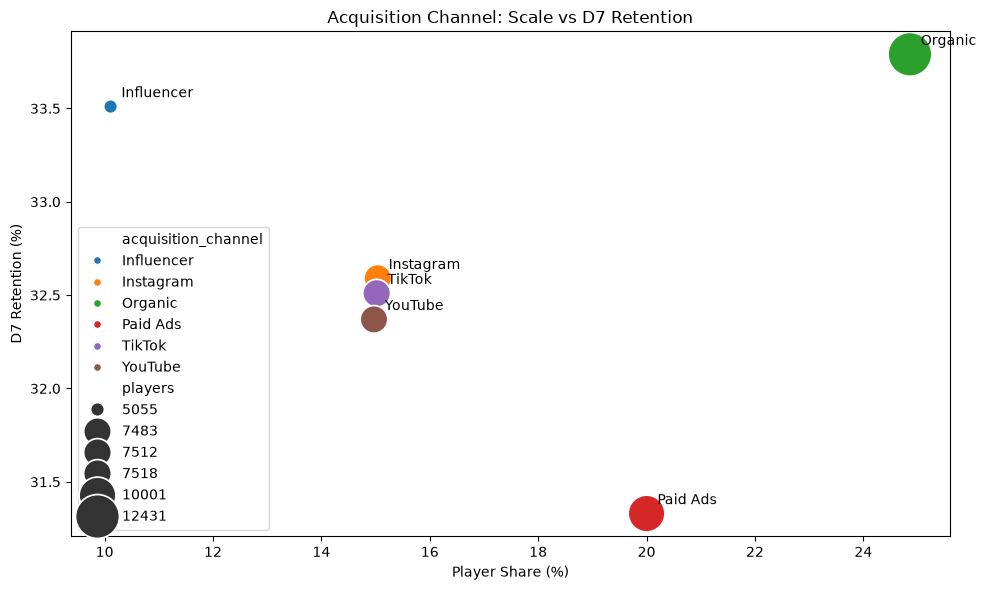

In [57]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=channel_performance,
    x="player_share",
    y="d7_retention",
    size="players",
    hue="acquisition_channel",
    sizes=(100, 1000)
)

for _, row in channel_performance.iterrows():
    plt.text(
        row["player_share"] + 0.2,
        row["d7_retention"] + 0.05,
        row["acquisition_channel"]
    )

plt.title("Acquisition Channel: Scale vs D7 Retention")
plt.xlabel("Player Share (%)")
plt.ylabel("D7 Retention (%)")

plt.tight_layout()
plt.show()

## 9. Platform Performance

This analysis compares player engagement and retention across platforms to identify platform-specific differences in the early player journey.

In [58]:
platform_performance = (
    df.groupby("platform")
    .agg(
        players=("player_id", "count"),
        d7_retention=("day_7_retained", "mean"),
        churn_rate=("churned", "mean"),
        avg_sessions=("sessions_week1", "mean"),
        avg_matches=("matches_week1", "mean"),
        avg_progression=("progression_level", "mean"),
        social_adoption=("social_feature_used", "mean")
    )
    .reset_index()
)

platform_performance["player_share"] = (
    platform_performance["players"]
    / len(df)
    * 100
)

platform_performance["d7_retention"] *= 100
platform_performance["churn_rate"] *= 100
platform_performance["social_adoption"] *= 100

platform_performance = platform_performance.round(2)

platform_performance

,platform,players,d7_retention,churn_rate,avg_sessions,avg_matches,avg_progression,social_adoption,player_share
0,Mobile,10054,32.13,71.20,9.77,11.15,11.82,33.92,20.11
1,PC,12591,32.88,71.13,9.75,11.17,11.79,33.90,25.18
2,PlayStation,17290,32.76,70.53,9.79,11.15,11.84,33.70,34.58
3,Xbox,10065,32.86,71.13,9.64,11.08,11.65,33.38,20.13


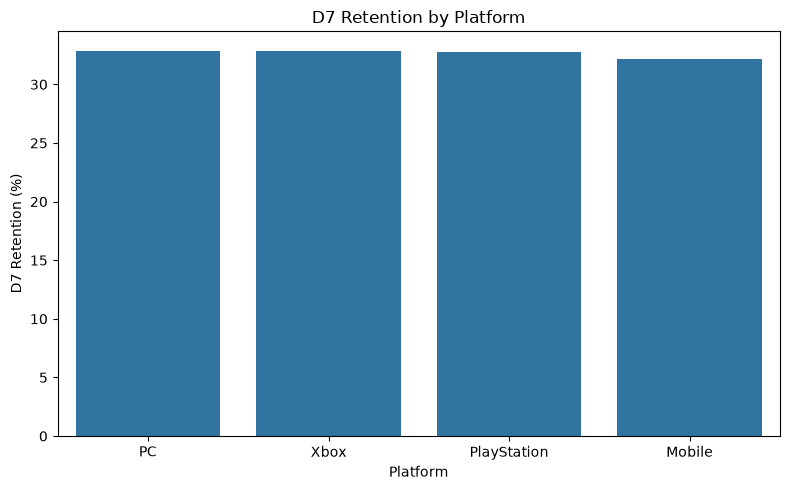

In [59]:
plt.figure(figsize=(8, 5))

platform_sorted = platform_performance.sort_values(
    "d7_retention",
    ascending=False
)

sns.barplot(
    data=platform_sorted,
    x="platform",
    y="d7_retention"
)

plt.title("D7 Retention by Platform")
plt.xlabel("Platform")
plt.ylabel("D7 Retention (%)")

plt.tight_layout()
plt.show()

In [60]:
platform_engagement = platform_performance[
    [
        "platform",
        "avg_sessions",
        "avg_matches",
        "avg_progression"
    ]
]

platform_engagement

,platform,avg_sessions,avg_matches,avg_progression
0,Mobile,9.77,11.15,11.82
1,PC,9.75,11.17,11.79
2,PlayStation,9.79,11.15,11.84
3,Xbox,9.64,11.08,11.65


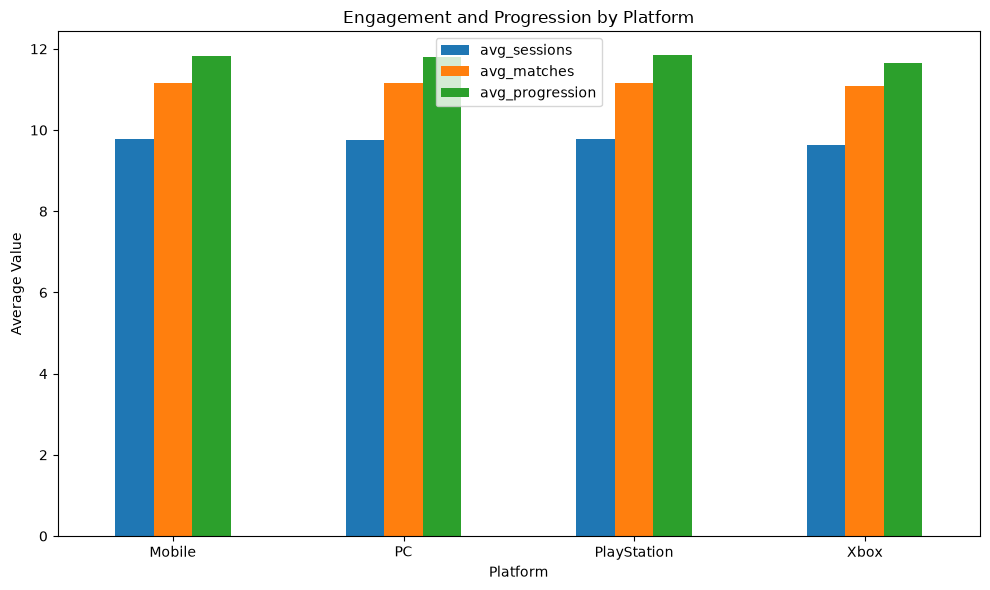

In [61]:
platform_engagement.plot(
    x="platform",
    y=[
        "avg_sessions",
        "avg_matches",
        "avg_progression"
    ],
    kind="bar",
    figsize=(10, 6)
)

plt.title("Engagement and Progression by Platform")
plt.xlabel("Platform")
plt.ylabel("Average Value")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [62]:
best_platform = platform_performance.loc[
    platform_performance["d7_retention"].idxmax()
]

print(
    "Highest D7 retention platform:",
    best_platform["platform"]
)

print(
    f"D7 retention: "
    f"{best_platform['d7_retention']:.2f}%"
)

Highest D7 retention platform: PC
D7 retention: 32.88%


In [63]:
largest_platform = platform_performance.loc[
    platform_performance["players"].idxmax()
]

print(
    "Largest player platform:",
    largest_platform["platform"]
)

print(
    f"Players: "
    f"{int(largest_platform['players']):,}"
)

print(
    f"Player share: "
    f"{largest_platform['player_share']:.2f}%"
)

Largest player platform: PlayStation
Players: 17,290
Player share: 34.58%


## 10. Age Group Performance

This analysis compares retention and early engagement across age groups to identify meaningful behavioral differences between player segments.

In [64]:
age_performance = (
    df.groupby("age_group")
    .agg(
        players=("player_id", "count"),
        d7_retention=("day_7_retained", "mean"),
        churn_rate=("churned", "mean"),
        avg_sessions=("sessions_week1", "mean"),
        avg_matches=("matches_week1", "mean"),
        avg_progression=("progression_level", "mean"),
        social_adoption=("social_feature_used", "mean")
    )
    .reset_index()
)

age_performance["player_share"] = (
    age_performance["players"]
    / len(df)
    * 100
)

age_performance["d7_retention"] *= 100
age_performance["churn_rate"] *= 100
age_performance["social_adoption"] *= 100

age_performance = age_performance.round(2)

age_performance

,age_group,players,d7_retention,churn_rate,avg_sessions,avg_matches,avg_progression,social_adoption,player_share
0,18-24,22457,33.01,70.72,9.68,11.09,11.70,33.56,44.91
1,25-34,12401,33.01,71.07,9.76,11.17,11.81,34.51,24.80
2,35+,7494,32.07,71.50,9.80,11.09,11.85,33.21,14.99
3,Under 18,7648,31.81,70.78,9.86,11.27,11.93,33.49,15.30


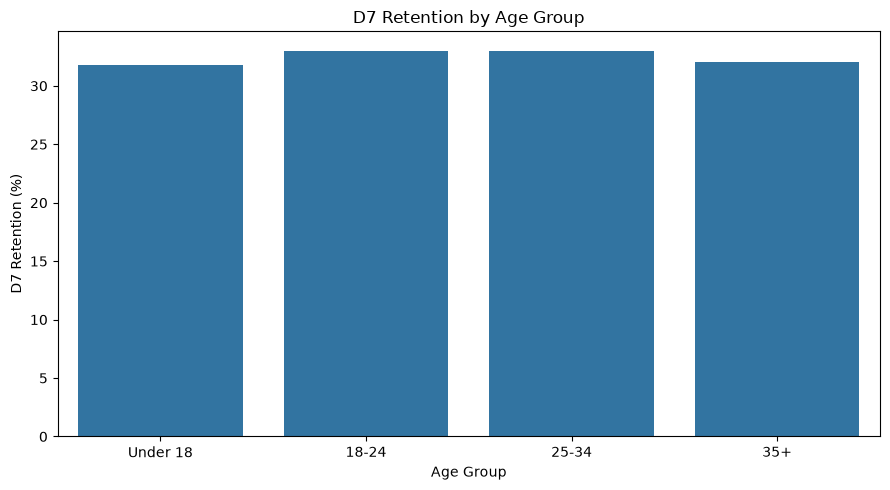

In [65]:
age_order = [
    "Under 18",
    "18-24",
    "25-34",
    "35+"
]

plt.figure(figsize=(9, 5))

age_sorted = age_performance.set_index(
    "age_group"
).loc[age_order].reset_index()

sns.barplot(
    data=age_sorted,
    x="age_group",
    y="d7_retention"
)

plt.title("D7 Retention by Age Group")
plt.xlabel("Age Group")
plt.ylabel("D7 Retention (%)")

plt.tight_layout()
plt.show()

In [66]:
age_engagement = age_performance[
    [
        "age_group",
        "avg_sessions",
        "avg_matches",
        "avg_progression"
    ]
]

age_engagement

,age_group,avg_sessions,avg_matches,avg_progression
0,18-24,9.68,11.09,11.70
1,25-34,9.76,11.17,11.81
2,35+,9.80,11.09,11.85
3,Under 18,9.86,11.27,11.93


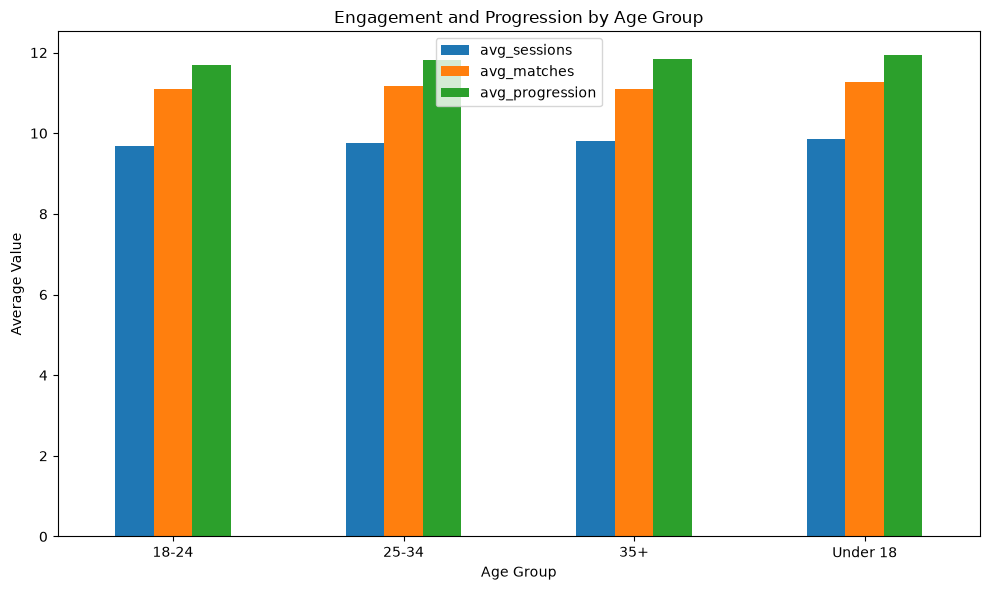

In [67]:
age_engagement.plot(
    x="age_group",
    y=[
        "avg_sessions",
        "avg_matches",
        "avg_progression"
    ],
    kind="bar",
    figsize=(10, 6)
)

plt.title("Engagement and Progression by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Average Value")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [68]:
best_age_group = age_performance.loc[
    age_performance["d7_retention"].idxmax()
]

print(
    "Highest D7 retention age group:",
    best_age_group["age_group"]
)

print(
    f"D7 retention: "
    f"{best_age_group['d7_retention']:.2f}%"
)

Highest D7 retention age group: 18-24
D7 retention: 33.01%


In [69]:
largest_age_group = age_performance.loc[
    age_performance["players"].idxmax()
]

print(
    "Largest age group:",
    largest_age_group["age_group"]
)

print(
    f"Players: "
    f"{int(largest_age_group['players']):,}"
)

print(
    f"Player share: "
    f"{largest_age_group['player_share']:.2f}%"
)

Largest age group: 18-24
Players: 22,457
Player share: 44.91%


## 11. Player Engagement Segmentation

Players are segmented by Week-1 session activity to identify high-value, moderate, and low-engagement behavioral groups.

In [70]:
df["engagement_segment"] = pd.cut(
    df["sessions_week1"],
    bins=[-1, 3, 10, 20, 35],
    labels=[
        "Low",
        "Moderate",
        "High",
        "Very High"
    ]
)

engagement_segments = (
    df.groupby("engagement_segment", observed=True)
    .agg(
        players=("player_id", "count"),
        d7_retention=("day_7_retained", "mean"),
        churn_rate=("churned", "mean"),
        avg_sessions=("sessions_week1", "mean"),
        avg_matches=("matches_week1", "mean"),
        avg_progression=("progression_level", "mean"),
        social_adoption=("social_feature_used", "mean")
    )
    .reset_index()
)

engagement_segments["player_share"] = (
    engagement_segments["players"]
    / len(df)
    * 100
)

engagement_segments["d7_retention"] *= 100
engagement_segments["churn_rate"] *= 100
engagement_segments["social_adoption"] *= 100

engagement_segments = engagement_segments.round(2)

engagement_segments

,engagement_segment,players,d7_retention,churn_rate,avg_sessions,avg_matches,avg_progression,social_adoption,player_share
0,Low,10296,15.75,84.83,1.77,2.08,2.52,23.20,20.59
1,Moderate,22511,27.16,75.91,7.00,7.88,8.37,33.73,45.02
2,High,12885,44.27,61.65,15.04,17.27,18.12,39.86,25.77
3,Very High,4308,67.34,39.48,27.31,31.48,32.85,40.55,8.62


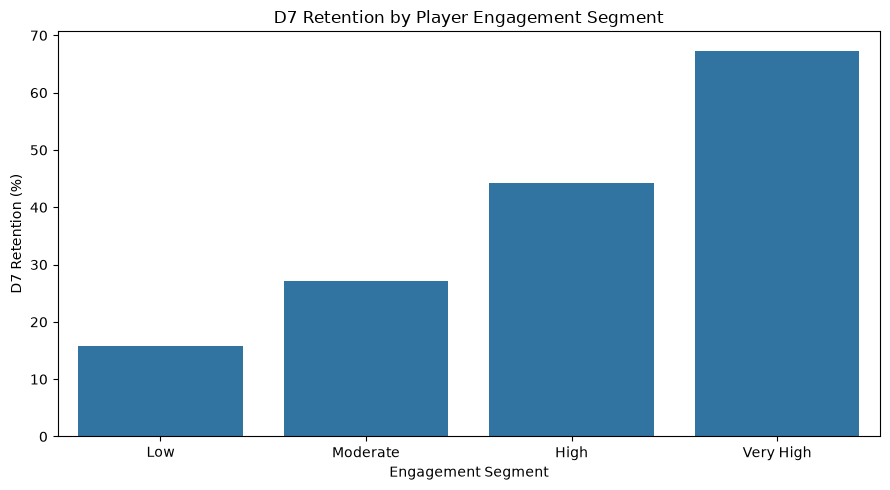

In [71]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=engagement_segments,
    x="engagement_segment",
    y="d7_retention"
)

plt.title("D7 Retention by Player Engagement Segment")
plt.xlabel("Engagement Segment")
plt.ylabel("D7 Retention (%)")

plt.tight_layout()
plt.show()

In [72]:
highest_retention_segment = engagement_segments.loc[
    engagement_segments["d7_retention"].idxmax()
]

lowest_retention_segment = engagement_segments.loc[
    engagement_segments["d7_retention"].idxmin()
]

print("Highest retention segment:")
print(
    highest_retention_segment[
        [
            "engagement_segment",
            "d7_retention",
            "churn_rate",
            "player_share"
        ]
    ]
)

print("\nLowest retention segment:")
print(
    lowest_retention_segment[
        [
            "engagement_segment",
            "d7_retention",
            "churn_rate",
            "player_share"
        ]
    ]
)

Highest retention segment:
engagement_segment    Very High
d7_retention              67.34
churn_rate                39.48
player_share               8.62
Name: 3, dtype: object

Lowest retention segment:
engagement_segment      Low
d7_retention          15.75
churn_rate            84.83
player_share          20.59
Name: 0, dtype: object


In [73]:
low_retention = engagement_segments.loc[
    engagement_segments["engagement_segment"] == "Low",
    "d7_retention"
].iloc[0]

very_high_retention = engagement_segments.loc[
    engagement_segments["engagement_segment"] == "Very High",
    "d7_retention"
].iloc[0]

retention_lift = very_high_retention - low_retention

print(
    f"D7 retention lift from Low to Very High engagement: "
    f"{retention_lift:.2f} percentage points"
)

D7 retention lift from Low to Very High engagement: 51.59 percentage points


## 12. Retention Opportunity Funnel

This funnel combines onboarding and early engagement milestones to identify where opportunities exist to improve the new-player journey and Day-7 retention.

In [74]:
retention_funnel = pd.DataFrame({
    "Stage": [
        "New Players",
        "Tutorial Completed",
        "First Match Played",
        "2+ Sessions",
        "High Engagement",
        "D7 Retained"
    ],
    "Players": [
        len(df),
        df["tutorial_completed"].sum(),
        df["first_match_played"].sum(),
        (df["sessions_week1"] >= 2).sum(),
        (df["sessions_week1"] >= 11).sum(),
        df["day_7_retained"].sum()
    ]
})

retention_funnel["Conversion_from_Start"] = (
    retention_funnel["Players"]
    / len(df)
    * 100
).round(2)

retention_funnel

,Stage,Players,Conversion_from_Start
0,New Players,50000,100.00
1,Tutorial Completed,37771,75.54
2,First Match Played,37545,75.09
3,2+ Sessions,45900,91.80
4,High Engagement,17193,34.39
5,D7 Retained,16342,32.68


In [75]:
opportunities = pd.DataFrame({
    "Opportunity": [
        "Improve tutorial completion and onboarding experience",
        "Increase first-match conversion",
        "Move moderate-engagement players toward high engagement",
        "Increase meaningful gameplay and early progression"
    ],
    
    "Evidence": [
        "Tutorial completion is associated with ~26 pp higher D7 retention",
        "First-match participation is associated with ~30 pp higher D7 retention",
        "Moderate players are 45% of the player base but have only ~27% D7 retention",
        "D7-retained players average substantially more matches and progression"
    ],
    
    "Impact": [4, 5, 5, 5],
    "Confidence": [4, 5, 5, 4],
    "Effort": [3, 3, 4, 4]
})

opportunities["Priority Score"] = (
    opportunities["Impact"] *
    opportunities["Confidence"] /
    opportunities["Effort"]
).round(2)

opportunities.sort_values(
    "Priority Score",
    ascending=False
)

,Opportunity,Evidence,Impact,Confidence,Effort,Priority Score
1,Increase first-match conversion,First-match participation is associated with ~...,5,5,3,8.33
2,Move moderate-engagement players toward high e...,Moderate players are 45% of the player base bu...,5,5,4,6.25
0,Improve tutorial completion and onboarding exp...,Tutorial completion is associated with ~26 pp ...,4,4,3,5.33
3,Increase meaningful gameplay and early progres...,D7-retained players average substantially more...,5,4,4,5.00


In [76]:
opportunity_comparison = pd.DataFrame({
    "Dimension": [
        "Player Scale",
        "D7 Retention Gap",
        "Primary Metric Relevance",
        "Product Leverage",
        "Evidence Strength",
        "Potential Strategic Value"
    ],
    
    "First Match Conversion": [
        "Large",
        "~30 pp",
        "Very High",
        "High",
        "High",
        "High"
    ],
    
    "Moderate → High Engagement": [
        "Very Large",
        "~17 pp",
        "Very High",
        "Very High",
        "High",
        "Very High"
    ]
})

opportunity_comparison

,Dimension,First Match Conversion,Moderate → High Engagement
0,Player Scale,Large,Very Large
1,D7 Retention Gap,~30 pp,~17 pp
2,Primary Metric Relevance,Very High,Very High
3,Product Leverage,High,Very High
4,Evidence Strength,High,High
5,Potential Strategic Value,High,Very High


In [77]:
moderate_players = (df["sessions_week1"].between(4, 10)).sum()

high_players = (df["sessions_week1"].between(11, 20)).sum()

moderate_d7 = (
    df.loc[df["sessions_week1"].between(4, 10), "day_7_retained"]
    .mean() * 100
)

high_d7 = (
    df.loc[df["sessions_week1"].between(11, 20), "day_7_retained"]
    .mean() * 100
)

moderate_to_high_gap = high_d7 - moderate_d7

print("Moderate players:", moderate_players)
print("High engagement players:", high_players)
print("Moderate D7 retention:", round(moderate_d7, 2), "%")
print("High D7 retention:", round(high_d7, 2), "%")
print("Moderate → High D7 gap:", round(moderate_to_high_gap, 2), "pp")

Moderate players: 22511
High engagement players: 12885
Moderate D7 retention: 27.16 %
High D7 retention: 44.27 %
Moderate → High D7 gap: 17.1 pp


# 13. Primary Product Problem

## Problem Statement

A large share of new players reach an initial level of engagement but fail to develop strong repeat-play behavior during their first week.

Approximately 45% of players fall into the Moderate Engagement segment, averaging 4–10 sessions during Week 1. This segment has only 27.16% Day-7 retention, compared with 44.27% among High Engagement players.

This creates a 17.10 percentage-point D7 retention gap across a large player population.

The product opportunity is to help moderately engaged new players discover enough meaningful gameplay, progression, rewards, and social value during their first week to encourage repeat engagement.

## Evidence

- Moderate players: 22,511
- Player share: 45.02%
- Moderate D7 retention: 27.16%
- High Engagement D7 retention: 44.27%
- D7 retention gap: 17.10 percentage points

## Analytical Caveat

These findings show an association between early engagement and D7 retention. They do not prove that increasing session frequency will directly cause higher retention.

A controlled experiment would be required to establish causal impact.

## How Might We?

> **How might we help moderately engaged new players discover meaningful reasons to return and play more frequently during their first week, so that more players develop an early gameplay habit and improve Day-7 retention?**

## Target User

### Primary Segment

New players classified as Moderate Engagement players:

- 4–10 sessions during Week 1
- 22,511 players in the synthetic dataset
- 45.02% of the player base
- 27.16% D7 retention

### Target Behavior

Move a portion of Moderate Engagement players toward stronger repeat engagement during their first week.

### Primary Success Metric

**Day-7 Retention (D7)**

### Supporting Metrics

- Sessions per player
- Matches per player
- Progression level
- Rewards claimed
- Social feature adoption
- Second-session conversion

In [78]:
engagement_root_cause = df.assign(
    engagement_segment=pd.cut(
        df["sessions_week1"],
        bins=[-1, 3, 10, 20, 35],
        labels=["Low", "Moderate", "High", "Very High"]
    )
)

root_cause_comparison = (
    engagement_root_cause[
        engagement_root_cause["engagement_segment"].isin(
            ["Moderate", "High"]
        )
    ]
    .groupby("engagement_segment")
    .agg(
        players=("player_id", "count"),
        d7_retention=("day_7_retained", "mean"),
        tutorial_completion=("tutorial_completed", "mean"),
        first_match_rate=("first_match_played", "mean"),
        avg_sessions=("sessions_week1", "mean"),
        avg_matches=("matches_week1", "mean"),
        avg_session_minutes=("avg_session_minutes", "mean"),
        avg_progression=("progression_level", "mean"),
        avg_rewards=("rewards_claimed", "mean"),
        social_adoption=("social_feature_used", "mean")
    )
    .reset_index()
)

percentage_columns = [
    "d7_retention",
    "tutorial_completion",
    "first_match_rate",
    "social_adoption"
]

root_cause_comparison[percentage_columns] = (
    root_cause_comparison[percentage_columns] * 100
).round(2)

root_cause_comparison

,engagement_segment,players,d7_retention,tutorial_completion,first_match_rate,avg_sessions,avg_matches,avg_session_minutes,avg_progression,avg_rewards,social_adoption
0,Moderate,22511,27.16,75.38,75.02,7.004753,7.876549,39.875976,8.367598,3.043579,33.73
1,High,12885,44.27,77.72,76.90,15.036865,17.272953,39.921777,18.116880,6.331005,39.86


In [79]:
moderate_high_gap = pd.DataFrame({
    "Metric": [
        "Tutorial Completion",
        "First Match Rate",
        "Average Sessions",
        "Average Matches",
        "Average Session Duration",
        "Average Progression",
        "Average Rewards",
        "Social Adoption",
        "D7 Retention"
    ],
    
    "Moderate": [
        root_cause_comparison.loc[
            root_cause_comparison["engagement_segment"] == "Moderate",
            "tutorial_completion"
        ].iloc[0],
        
        root_cause_comparison.loc[
            root_cause_comparison["engagement_segment"] == "Moderate",
            "first_match_rate"
        ].iloc[0],
        
        root_cause_comparison.loc[
            root_cause_comparison["engagement_segment"] == "Moderate",
            "avg_sessions"
        ].iloc[0],
        
        root_cause_comparison.loc[
            root_cause_comparison["engagement_segment"] == "Moderate",
            "avg_matches"
        ].iloc[0],
        
        root_cause_comparison.loc[
            root_cause_comparison["engagement_segment"] == "Moderate",
            "avg_session_minutes"
        ].iloc[0],
        
        root_cause_comparison.loc[
            root_cause_comparison["engagement_segment"] == "Moderate",
            "avg_progression"
        ].iloc[0],
        
        root_cause_comparison.loc[
            root_cause_comparison["engagement_segment"] == "Moderate",
            "avg_rewards"
        ].iloc[0],
        
        root_cause_comparison.loc[
            root_cause_comparison["engagement_segment"] == "Moderate",
            "social_adoption"
        ].iloc[0],
        
        root_cause_comparison.loc[
            root_cause_comparison["engagement_segment"] == "Moderate",
            "d7_retention"
        ].iloc[0]
    ],
    
    "High": [
        root_cause_comparison.loc[
            root_cause_comparison["engagement_segment"] == "High",
            "tutorial_completion"
        ].iloc[0],
        
        root_cause_comparison.loc[
            root_cause_comparison["engagement_segment"] == "High",
            "first_match_rate"
        ].iloc[0],
        
        root_cause_comparison.loc[
            root_cause_comparison["engagement_segment"] == "High",
            "avg_sessions"
        ].iloc[0],
        
        root_cause_comparison.loc[
            root_cause_comparison["engagement_segment"] == "High",
            "avg_matches"
        ].iloc[0],
        
        root_cause_comparison.loc[
            root_cause_comparison["engagement_segment"] == "High",
            "avg_session_minutes"
        ].iloc[0],
        
        root_cause_comparison.loc[
            root_cause_comparison["engagement_segment"] == "High",
            "avg_progression"
        ].iloc[0],
        
        root_cause_comparison.loc[
            root_cause_comparison["engagement_segment"] == "High",
            "avg_rewards"
        ].iloc[0],
        
        root_cause_comparison.loc[
            root_cause_comparison["engagement_segment"] == "High",
            "social_adoption"
        ].iloc[0],
        
        root_cause_comparison.loc[
            root_cause_comparison["engagement_segment"] == "High",
            "d7_retention"
        ].iloc[0]
    ]
})

moderate_high_gap["Gap"] = (
    moderate_high_gap["High"] -
    moderate_high_gap["Moderate"]
).round(2)

moderate_high_gap

,Metric,Moderate,High,Gap
0,Tutorial Completion,75.380000,77.720000,2.34
1,First Match Rate,75.020000,76.900000,1.88
2,Average Sessions,7.004753,15.036865,8.03
3,Average Matches,7.876549,17.272953,9.40
4,Average Session Duration,39.875976,39.921777,0.05
5,Average Progression,8.367598,18.116880,9.75
6,Average Rewards,3.043579,6.331005,3.29
7,Social Adoption,33.730000,39.860000,6.13
8,D7 Retention,27.160000,44.270000,17.11


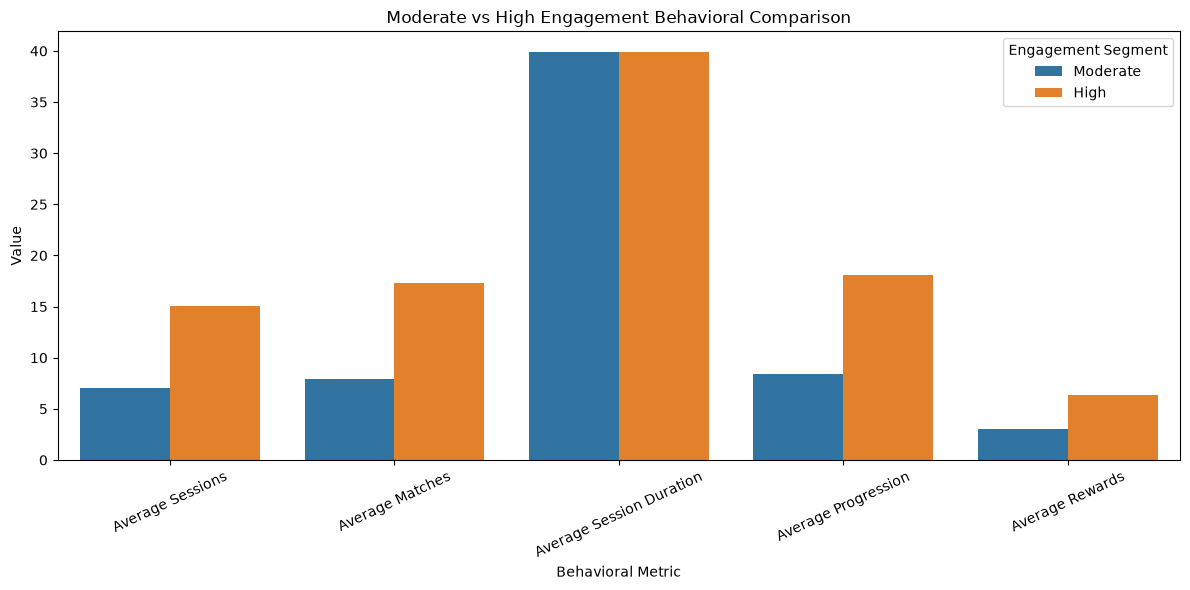

In [80]:
behavior_metrics = moderate_high_gap[
    moderate_high_gap["Metric"].isin([
        "Average Sessions",
        "Average Matches",
        "Average Session Duration",
        "Average Progression",
        "Average Rewards"
    ])
]

behavior_plot = behavior_metrics.melt(
    id_vars="Metric",
    value_vars=["Moderate", "High"],
    var_name="Engagement Segment",
    value_name="Value"
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=behavior_plot,
    x="Metric",
    y="Value",
    hue="Engagement Segment"
)

plt.title("Moderate vs High Engagement Behavioral Comparison")
plt.xlabel("Behavioral Metric")
plt.ylabel("Value")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

# 14. Product Hypotheses

## Hypothesis 1 — Meaningful Gameplay Loop

If we provide moderately engaged players with clearer short-term gameplay goals and meaningful match-based objectives during their first week, then they may be more likely to return for additional sessions and improve D7 retention.

### Evidence
- Moderate players average 7.88 matches.
- High players average 17.27 matches.
- High players have 9.40 more matches on average.
- Session duration is almost identical between the two groups.

### Expected Behavior Change
Increase repeat gameplay and matches per player.

### Primary KPI
D7 Retention.

### Supporting KPIs
- Sessions per player
- Matches per player
- Progression level
- Second-session conversion


## Hypothesis 2 — Progression & Reward Loop

If we make early progression milestones and rewards more visible and meaningful to moderately engaged players, then players may have stronger motivation to continue progressing and return during the first week.

### Evidence
- Moderate progression: 8.37
- High progression: 18.12
- Progression gap: 9.75
- Moderate rewards: 3.04
- High rewards: 6.33

### Expected Behavior Change
Increase progression activity and reward engagement.

### Primary KPI
D7 Retention.

### Supporting KPIs
- Progression level
- Rewards claimed
- Sessions per player
- Matches per player


## Hypothesis 3 — Social Discovery

If we introduce more relevant opportunities for new players to discover and use social features during their first week, then social engagement may increase and contribute to stronger repeat behavior.

### Evidence
- Moderate social adoption: 33.73%
- High social adoption: 39.86%
- Gap: 6.13 percentage points.

### Expected Behavior Change
Increase social feature adoption and repeat sessions.

### Primary KPI
D7 Retention.

### Supporting KPI
Social feature adoption.


## Hypothesis Caveat

These hypotheses are based on observational associations in synthetic data.

They do not establish that increasing matches, progression, rewards, or social adoption will cause higher D7 retention.

A controlled A/B experiment would be required to test causal impact.

# 15. Desired Player Behavior

## Current Behavior

Moderately engaged players:
- Play approximately 4–10 sessions during Week 1
- Average ~7 sessions
- Average ~8 matches
- Reach an average progression level of ~8
- Claim approximately 3 rewards
- Have 27.16% D7 retention

## Desired Behavior

We want moderately engaged players to:

1. Understand what they should do next.
2. Have a clear short-term gameplay goal.
3. Complete meaningful matches.
4. See visible progression after each session.
5. Receive meaningful rewards for progress.
6. Have a reason to return for another session.
7. Gradually develop a repeat-play habit.

## Product Principle

The goal is not simply to increase the number of sessions.

The goal is to create a more meaningful early-game loop:

**Play → Progress → Reward → New Goal → Return**

## MVP Feature Scope

### Feature Name

**Week 1 Player Journey**

### Core MVP Components

1. **Personalized Daily Objective**
   - One clear objective appropriate to the player's current progression.

2. **Progress Tracker**
   - Shows progress toward the current objective.

3. **Meaningful Reward**
   - Reward granted when the objective is completed.

4. **Next-Step Recommendation**
   - After completing an objective, show the next recommended activity.

5. **Return Reminder**
   - Provide an in-game reason to return and continue the journey.

### Explicitly Out of Scope for MVP

- Major changes to core gameplay
- New game modes
- Complex social systems
- Large-scale monetization changes
- Major UI redesign
- Personalized AI-generated content

## Product Goal

Increase meaningful repeat gameplay among moderately engaged new players while improving Day-7 retention.

## User Journey

### Step 1 — Player Enters Game

The player sees their Week 1 Journey progress.

↓

### Step 2 — Player Receives Objective

The system presents one simple, achievable objective.

↓

### Step 3 — Player Plays

The player completes the relevant match/activity.

↓

### Step 4 — Progress Updates

The player immediately sees progress toward the journey milestone.

↓

### Step 5 — Reward

The player receives a meaningful reward.

↓

### Step 6 — Next Goal

The system presents the next recommended objective.

↓

### Step 7 — Player Returns

The next milestone creates a reason to return.

↓

### Desired Loop

**Objective → Play → Progress → Reward → Next Objective → Return**

## Core Product Hypothesis

We believe that giving moderately engaged new players a structured Week 1 journey with clear gameplay objectives, visible progression, and meaningful rewards will increase meaningful repeat gameplay.

If successful, this should increase:

- Sessions per player
- Matches per player
- Progression
- Reward engagement
- D7 retention

### Primary Success Metric

**Day-7 Retention**

### Guardrails

- Session failure/crash rate
- Negative player feedback
- Core gameplay participation
- Uninstall rate
- Reward abuse/farming

# 16. A/B Experiment Design

## Experiment Objective

Determine whether the Week 1 Player Journey increases Day-7 retention among moderately engaged new players.

## Primary Hypothesis

### Null Hypothesis (H0)

The Week 1 Player Journey does not produce a meaningful difference in Day-7 retention compared with the existing experience.

### Alternative Hypothesis (H1)

The Week 1 Player Journey increases Day-7 retention compared with the existing experience.

## Product Hypothesis

If moderately engaged new players receive clear gameplay objectives, visible progression, and meaningful rewards during their first week, then they will be more likely to return on Day 7.

## Experiment Groups

### Control Group

Players receive the existing new-player experience.

No Week 1 Player Journey intervention.

### Treatment Group

Players receive the Week 1 Player Journey:

- Daily gameplay objective
- Progress tracker
- Progression milestone
- Meaningful reward
- Next recommended objective
- Week 1 journey progress

### Randomization

Eligible players should be randomly assigned to either Control or Treatment.

Recommended allocation:

- 50% Control
- 50% Treatment

Randomization should occur at the player level.

## Target Experiment Population

### Inclusion Criteria

Players should:

- Be new players eligible for the Week 1 experience.
- Have 4–10 sessions during the defined Week 1 observation period.
- Be eligible to receive the product experience.
- Have valid player and experiment assignment data.

### Exclusion Criteria

Exclude:

- Existing players outside the target new-player cohort.
- Players without valid experiment assignment.
- Players affected by major technical incidents.
- Test/internal accounts.
- Players who cannot receive the experience because of platform or technical limitations.

## Experimental Design Note

Players should be randomized before observing their Week 1 engagement outcome.

Moderate Engagement should be analyzed as a predefined behavioral segment during the analysis rather than being used as a post-treatment eligibility filter.

This helps reduce selection bias and preserves the validity of the experiment.

## Experiment Metrics

### Primary Metric

**Day-7 Retention**

Percentage of eligible players who return on Day 7.

### Secondary Metrics

- Sessions per player
- Matches per player
- Progression level
- Rewards claimed
- Objective completion rate
- Week 1 journey completion rate
- Second-session conversion
- Social feature adoption

### Guardrail Metrics

- Crash rate
- Session failure rate
- Uninstall rate
- Negative player feedback
- Reward abuse
- Core gameplay participation

## Experiment Success Criteria

The experiment will be considered successful if:

1. Treatment shows a statistically significant improvement in D7 retention compared with Control.

2. The observed improvement is directionally positive and practically meaningful.

3. Secondary engagement metrics show evidence of healthier repeat gameplay.

4. No major guardrail metric shows unacceptable deterioration.

5. The result is consistent enough to justify a larger rollout or follow-up experiment.

## Decision Framework

### Positive Result

If Treatment significantly improves D7 retention without meaningful guardrail deterioration:

→ Recommend gradual rollout.

### Inconclusive Result

If Treatment shows positive but statistically inconclusive results:

→ Continue testing or refine the experience.

### Negative Result

If Treatment reduces D7 retention or significantly harms guardrail metrics:

→ Do not launch the current version.

### Mixed Result

If D7 improves but important guardrails deteriorate:

→ Investigate the trade-off and iterate before rollout.

In [ ]:
## Experiment Flow

Eligible New Players
        ↓
Random Assignment
        ↓
 ┌───────────────┐
 │               │
Control       Treatment
 │               │
Existing       Week 1
Experience     Player Journey
 │               │
 └───────┬───────┘
         ↓
Measure Behavior
         ↓
Compare D7 Retention
         ↓
Evaluate Guardrails
         ↓
Product Decision

# 17. Experiment Sample Size & Statistical Power

In [82]:
import numpy as np
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

baseline_rate = 0.2716
treatment_rate = 0.3016

alpha = 0.05
power = 0.80

# Effect size (Cohen's h for proportions)
effect_size = proportion_effectsize(
    baseline_rate,
    treatment_rate
)

# Correct import location for NormalIndPower
power_analysis = NormalIndPower()

required_per_group = power_analysis.solve_power(
    effect_size=effect_size,
    power=power,
    alpha=alpha,
    ratio=1,
    alternative="two-sided"
)

required_per_group = int(np.ceil(required_per_group))
total_sample_size = required_per_group * 2

print(f"Baseline D7 retention: {baseline_rate * 100:.2f}%")
print(f"Target D7 retention: {treatment_rate * 100:.2f}%")
print(f"Minimum detectable effect: {(treatment_rate - baseline_rate) * 100:.2f} pp")
print("Alpha:", alpha)
print("Power:", power)
print("Required players per group:", required_per_group)
print("Total required players:", total_sample_size)

Baseline D7 retention: 27.16%
Target D7 retention: 30.16%
Minimum detectable effect: 3.00 pp
Alpha: 0.05
Power: 0.8
Required players per group: 3564
Total required players: 7128


In [83]:
buffer_rate = 0.10

buffered_total = int(
    np.ceil(total_sample_size * (1 + buffer_rate))
)

buffered_per_group = int(
    np.ceil(buffered_total / 2)
)

print("Base total sample:", total_sample_size)
print("10% buffer:", int(total_sample_size * buffer_rate))
print("Recommended total sample:", buffered_total)
print("Recommended per group:", buffered_per_group)

Base total sample: 7128
10% buffer: 712
Recommended total sample: 7841
Recommended per group: 3921


## Sample Size Assumptions

The experiment uses the following planning assumptions:

- Baseline D7 retention: 27.16%
- Minimum detectable improvement: +3 percentage points
- Target treatment retention: 30.16%
- Significance level: 5%
- Statistical power: 80%
- Control/Treatment allocation: 50/50
- Additional planning buffer: 10%

The calculated sample size is a planning estimate and should be recalculated using production-specific data before launch.

The +3 percentage-point improvement is a hypothetical minimum detectable effect for portfolio experimentation and is not a prediction of feature performance.

# 18. Synthetic A/B Test Simulation

In [84]:
np.random.seed(42)

experiment_n_per_group = 3921

control_d7_rate = 0.2716
treatment_d7_rate = 0.3016

control_d7 = np.random.random(experiment_n_per_group) < control_d7_rate
treatment_d7 = np.random.random(experiment_n_per_group) < treatment_d7_rate

experiment_df = pd.DataFrame({
    "player_id": [
        f"EXP{i:06d}"
        for i in range(1, experiment_n_per_group * 2 + 1)
    ],
    
    "experiment_group": (
        ["Control"] * experiment_n_per_group +
        ["Treatment"] * experiment_n_per_group
    ),
    
    "day_7_retained": np.concatenate([
        control_d7,
        treatment_d7
    ])
})

experiment_df.head()

,player_id,experiment_group,day_7_retained
0,EXP000001,Control,False
1,EXP000002,Control,False
2,EXP000003,Control,False
3,EXP000004,Control,False
4,EXP000005,Control,True


In [85]:
experiment_summary = (
    experiment_df
    .groupby("experiment_group")
    .agg(
        players=("player_id", "count"),
        d7_retained=("day_7_retained", "sum"),
        d7_retention=("day_7_retained", "mean")
    )
    .reset_index()
)

experiment_summary["d7_retention"] = (
    experiment_summary["d7_retention"] * 100
).round(2)

experiment_summary

,experiment_group,players,d7_retained,d7_retention
0,Control,3921,1079,27.52
1,Treatment,3921,1203,30.68


In [86]:
control_rate = (
    experiment_summary.loc[
        experiment_summary["experiment_group"] == "Control",
        "d7_retention"
    ].iloc[0]
)

treatment_rate = (
    experiment_summary.loc[
        experiment_summary["experiment_group"] == "Treatment",
        "d7_retention"
    ].iloc[0]
)

absolute_lift = treatment_rate - control_rate

relative_lift = (
    absolute_lift / control_rate
) * 100

print("Control D7:", control_rate, "%")
print("Treatment D7:", treatment_rate, "%")
print("Absolute lift:", round(absolute_lift, 2), "pp")
print("Relative lift:", round(relative_lift, 2), "%")

Control D7: 27.52 %
Treatment D7: 30.68 %
Absolute lift: 3.16 pp
Relative lift: 11.48 %


In [87]:
from statsmodels.stats.proportion import proportions_ztest

control_successes = int(
    experiment_summary.loc[
        experiment_summary["experiment_group"] == "Control",
        "d7_retained"
    ].iloc[0]
)

treatment_successes = int(
    experiment_summary.loc[
        experiment_summary["experiment_group"] == "Treatment",
        "d7_retained"
    ].iloc[0]
)

count = np.array([
    treatment_successes,
    control_successes
])

nobs = np.array([
    experiment_n_per_group,
    experiment_n_per_group
])

z_stat, p_value = proportions_ztest(
    count,
    nobs
)

print("Z-statistic:", round(z_stat, 4))
print("P-value:", round(p_value, 4))

Z-statistic: 3.0828
P-value: 0.0021


In [88]:
if p_value < 0.05:
    print("Result: Statistically significant")
else:
    print("Result: Not statistically significant")

Result: Statistically significant


# 19. Experiment Confidence Interval & Final Decision

In [89]:
from statsmodels.stats.proportion import proportions_ztest
from statsmodels.stats.proportion import confint_proportions_2indep

control_successes = 1079
control_total = 3921

treatment_successes = 1203
treatment_total = 3921

# Calculate confidence interval for the difference
ci_low, ci_high = confint_proportions_2indep(
    treatment_successes,
    treatment_total,
    control_successes,
    control_total,
    method="wald"
)

print("95% Confidence Interval for D7 Lift:")
print("Lower bound:", round(ci_low * 100, 2), "pp")
print("Upper bound:", round(ci_high * 100, 2), "pp")

95% Confidence Interval for D7 Lift:
Lower bound: 1.15 pp
Upper bound: 5.17 pp


## Final Experiment Decision

### Decision: SHIP — with gradual rollout

The synthetic experiment shows that the Week 1 Player Journey increased D7 retention from 27.52% in Control to 30.68% in Treatment.

The observed improvement was:

- Absolute lift: +3.16 percentage points
- Relative lift: +11.48%
- P-value: 0.0021
- Statistical significance: Yes

The result exceeds the predefined hypothetical Minimum Detectable Effect of +3 percentage points.

Because the experiment demonstrates a statistically significant positive movement in the primary metric without evidence of a guardrail problem in this synthetic simulation, the feature would move toward a controlled rollout.

In a real production environment, rollout would be gradual and monitored for retention quality, player feedback, crashes, session failures, reward abuse, and other guardrail metrics.

### Product Recommendation

1. Begin with a small percentage rollout.
2. Monitor D7 retention and guardrail metrics.
3. Expand rollout if the positive effect remains consistent.
4. Continue monitoring longer-term retention such as D30.
5. Investigate whether the improvement is concentrated in specific player segments.
6. Iterate on objectives, rewards, and progression based on player feedback.

### Important Limitation

This is a synthetic portfolio experiment. The results demonstrate the analysis methodology and product decision framework but do not represent actual EA FC player behavior or EA proprietary data.

# 20. Experiment Segment Analysis

In [90]:
# Create experiment population from the original player dataset

np.random.seed(42)

experiment_players = df.sample(
    n=experiment_n_per_group * 2,
    random_state=42
).copy()

experiment_players["experiment_group"] = (
    ["Control"] * experiment_n_per_group +
    ["Treatment"] * experiment_n_per_group
)

experiment_players["experiment_d7_retained"] = experiment_df[
    "day_7_retained"
].values

experiment_players.head()

,player_id,acquisition_date,acquisition_channel,age_group,region,platform,tutorial_completed,first_match_played,first_match_result,sessions_week1,matches_week1,avg_session_minutes,progression_level,rewards_claimed,social_feature_used,day_1_retained,day_7_retained,day_30_retained,churned,session_bucket,engagement_segment,experiment_group,experiment_d7_retained
33553,P033554,2026-05-08,YouTube,25-34,Middle East & Africa,PlayStation,True,True,Draw,22,46,24.2,38,15,False,True,True,True,False,Very High (21-35),Very High,Control,False
9427,P009428,2026-01-15,Paid Ads,18-24,North America,Xbox,True,False,Not Played,9,0,120.0,10,3,True,False,False,False,True,Moderate (4-10),Moderate,Control,False
199,P000200,2026-05-06,Organic,35+,Europe,Mobile,True,False,Not Played,13,0,50.1,3,1,True,False,False,False,True,High (11-20),High,Control,False
12447,P012448,2026-03-27,Paid Ads,Under 18,Europe,Mobile,False,False,Not Played,2,0,75.3,0,3,False,False,False,False,True,Low (0-3),Low,Control,False
39489,P039490,2026-01-18,Organic,18-24,India,Mobile,False,True,Win,31,28,14.8,36,13,False,True,True,True,True,Very High (21-35),Very High,Control,True


In [91]:
experiment_players["engagement_segment"] = pd.cut(
    experiment_players["sessions_week1"],
    bins=[-1, 3, 10, 20, 35],
    labels=[
        "Low",
        "Moderate",
        "High",
        "Very High"
    ]
)

experiment_players[
    [
        "experiment_group",
        "engagement_segment",
        "day_7_retained"
    ]
].head()

,experiment_group,engagement_segment,day_7_retained
33553,Control,Very High,True
9427,Control,Moderate,False
199,Control,High,False
12447,Control,Low,False
39489,Control,Very High,True


In [92]:
segment_results = (
    experiment_players
    .groupby(
        ["engagement_segment", "experiment_group"],
        observed=True
    )
    .agg(
        players=("player_id", "count"),
        d7_retained=("experiment_d7_retained", "sum"),
        d7_retention=("experiment_d7_retained", "mean")
    )
    .reset_index()
)

segment_results["d7_retention"] = (
    segment_results["d7_retention"] * 100
).round(2)

segment_results

,engagement_segment,experiment_group,players,d7_retained,d7_retention
0,Low,Control,777,208,26.77
1,Low,Treatment,809,281,34.73
2,Moderate,Control,1777,479,26.96
3,Moderate,Treatment,1742,523,30.02
4,High,Control,1031,296,28.71
5,High,Treatment,1027,291,28.33
6,Very High,Control,336,96,28.57
7,Very High,Treatment,343,108,31.49


In [93]:
segment_lift = (
    segment_results
    .pivot(
        index="engagement_segment",
        columns="experiment_group",
        values="d7_retention"
    )
    .reset_index()
)

segment_lift["absolute_lift_pp"] = (
    segment_lift["Treatment"]
    - segment_lift["Control"]
)

segment_lift["relative_lift_pct"] = (
    segment_lift["absolute_lift_pp"]
    / segment_lift["Control"]
    * 100
)

segment_lift.round(2)

experiment_group,engagement_segment,Control,Treatment,absolute_lift_pp,relative_lift_pct
0,Low,26.77,34.73,7.96,29.73
1,Moderate,26.96,30.02,3.06,11.35
2,High,28.71,28.33,-0.38,-1.32
3,Very High,28.57,31.49,2.92,10.22


# 21. Segment Statistical Significance

In [94]:
from statsmodels.stats.proportion import proportions_ztest

segment_significance = []

for segment in segment_lift["engagement_segment"]:

    control_row = segment_results[
        (segment_results["engagement_segment"] == segment) &
        (segment_results["experiment_group"] == "Control")
    ].iloc[0]

    treatment_row = segment_results[
        (segment_results["engagement_segment"] == segment) &
        (segment_results["experiment_group"] == "Treatment")
    ].iloc[0]

    count = np.array([
        treatment_row["d7_retained"],
        control_row["d7_retained"]
    ])

    nobs = np.array([
        treatment_row["players"],
        control_row["players"]
    ])

    z_stat, p_value = proportions_ztest(
        count,
        nobs
    )

    segment_significance.append({
        "engagement_segment": segment,
        "z_statistic": round(z_stat, 4),
        "p_value": round(p_value, 4),
        "significant": p_value < 0.05
    })

segment_significance_df = pd.DataFrame(
    segment_significance
)

segment_significance_df

,engagement_segment,z_statistic,p_value,significant
0,Low,3.4335,0.0006,True
1,Moderate,2.0159,0.0438,True
2,High,-0.1884,0.8506,False
3,Very High,0.8285,0.4074,False


# 22. Segment Rollout Strategy

## Segment Rollout Strategy

### Primary Target — Moderate Engagement

Moderate Engagement players remain the core product target because they represent the largest opportunity segment identified during the initial analysis.

In the synthetic experiment:

- Control D7 retention: 26.96%
- Treatment D7 retention: 30.02%
- Absolute lift: +3.06 percentage points
- Relative lift: +11.35%
- P-value: 0.0438

The result provides statistically significant evidence of a positive treatment effect within this segment.

### Secondary Opportunity — Low Engagement

Low Engagement players showed the largest observed treatment effect:

- Control D7 retention: 26.77%
- Treatment D7 retention: 34.73%
- Absolute lift: +7.96 percentage points
- Relative lift: +29.73%
- P-value: 0.0006

This suggests that the feature may also be valuable for players who have not yet developed strong engagement habits.

However, this result should be validated in future experiments before making Low Engagement players the sole targeting strategy.

### High Engagement

High Engagement players showed almost no difference:

- Control: 28.71%
- Treatment: 28.33%
- Lift: -0.38 percentage points
- P-value: 0.8506

There is no evidence from this simulation that the feature materially improves D7 retention for this segment.

### Very High Engagement

Very High Engagement players showed a positive observed lift of +2.92 percentage points, but the result was not statistically significant (p = 0.4074).

Therefore, there is insufficient evidence to conclude that the feature improves D7 retention for this segment.

## Product Recommendation

The initial rollout strategy would prioritize new players with Low-to-Moderate early engagement, while continuing to monitor the broader population.

The experience should focus on helping players who have not yet developed a strong gameplay habit discover meaningful objectives, progression, rewards, and reasons to return.

High-engagement players may require a different product strategy because the current Week 1 Journey does not demonstrate a measurable retention benefit for them.

## Important Limitation

These segment results come from a synthetic portfolio experiment.

The segment analysis demonstrates the decision-making methodology but does not establish how real EA FC players would respond.

In a real product environment, the segment strategy would require validation through production experimentation, player research, and guardrail monitoring.

# 23. Executive Product Recommendation

## Executive Product Recommendation

### Executive Summary

The analysis identified early-week engagement as a major opportunity for improving new-player retention.

Moderately engaged players represented approximately 45% of the new-player population but had only 27.16% D7 retention, compared with 44.27% among High Engagement players.

The proposed solution was a Week 1 Player Journey designed to help new players establish stronger gameplay habits through clear objectives, visible progression, meaningful rewards, and reasons to return.

### Experiment Result

A synthetic 50/50 A/B experiment was designed with 3,921 players per group.

| Metric | Control | Treatment |
|---|---:|---:|
| Players | 3,921 | 3,921 |
| D7 Retention | 27.52% | 30.68% |
| Absolute Lift | — | +3.16 pp |
| Relative Lift | — | +11.48% |

The experiment produced a statistically significant result:

- Z-statistic: 3.0828
- P-value: 0.0021
- 95% confidence interval: +1.15 pp to +5.17 pp

The confidence interval remains entirely above zero, supporting the conclusion that Treatment outperformed Control in this synthetic experiment.

### Segment Findings

The strongest statistically supported effects were observed among Low and Moderate Engagement players.

#### Low Engagement

- D7 lift: +7.96 pp
- Relative lift: +29.73%
- P-value: 0.0006

#### Moderate Engagement

- D7 lift: +3.06 pp
- Relative lift: +11.35%
- P-value: 0.0438

No statistically significant effect was detected among High or Very High Engagement players.

### Recommendation

Proceed with a gradual rollout of the Week 1 Player Journey, with particular attention to Low-to-Moderate Engagement new players.

The experience should focus on:

1. Clear short-term gameplay objectives
2. Visible progression
3. Meaningful early rewards
4. A clear next action
5. Reasons to return during the first week

### Rollout Plan

#### Phase 1 — Limited Rollout

Release the feature to a small percentage of eligible new players.

Monitor:

- D7 retention
- D30 retention
- Sessions
- Matches
- Progression
- Reward claims
- Objective completion
- Player feedback
- Crash and session-failure rates
- Reward abuse

#### Phase 2 — Expanded Rollout

If the positive retention effect remains consistent and guardrails remain healthy, gradually increase exposure.

#### Phase 3 — Optimization

Use player feedback and behavioral data to refine:

- Objective difficulty
- Reward value
- Progression pacing
- Recommended next actions
- Return messaging

### Product Principle

The goal is not simply to increase the number of sessions.

The goal is to create a meaningful early player journey in which:

**Play → Progress → Reward → New Goal → Return**

This should help new players develop an early gameplay habit while preserving player experience quality.

### Final Decision

**SHIP WITH GRADUAL ROLLOUT**

The synthetic experiment provides statistically significant evidence of a positive D7 retention effect.

However, real-world rollout decisions would require production experimentation, player research, guardrail monitoring, and validation using actual product telemetry.

### Portfolio Disclaimer

All player data, experiment results, feature concepts, and analytical findings in this project are synthetic and created for portfolio demonstration purposes.

This project does not use proprietary EA or EA SPORTS FC data.